# Week 4 Lab — Classic ML I: Distance & Boundary

## 실습 목표
1. **스케일링(Scaling)** 이 왜 필요한지 수치와 시각화로 확인한다.
2. **KNN (거리 기반)** 과 **SVM (경계 기반)** 의 차이를 직접 비교한다.
3. `Pipeline(Scaler + Model)` 구조로 **누수 없는 baseline 모델링**을 구현한다.
4. **데이터 스케일링 유무에 따른 SVM 성능 차이**를 실험한다.
5. 마지막으로 **타이타닉 과제용 Pipeline 템플릿**까지 연결한다.

---

### 오늘 실습 데이터
- 본 실습은 **Scikit-learn Breast Cancer Wisconsin** 데이터를 사용합니다.
- 이유:
  - **수치형 변수만으로 구성**되어 있어 스케일링 효과를 보기 좋음
  - **이진 분류 문제**라 Accuracy / F1 / Confusion Matrix 비교가 쉬움
  - KNN / SVM baseline 비교에 적합

> 오늘 핵심은 **“어떤 모델이 더 좋다”** 가 아니라,  
> **“전처리와 모델이 함께 성능을 만든다”** 를 체감하는 것입니다.


> **🗣️ [발표자 스크립트]**  
> "오늘 실습은 4주차 이론의 핵심인 스케일링, KNN, SVM, 그리고 Pipeline을 직접 연결해보는 시간입니다.  
> 먼저 순수 수치형 데이터로 스케일링 효과를 명확히 체감하고,  
> 마지막에는 과제 2인 타이타닉 생존자 예측으로 자연스럽게 넘어갈 수 있게 템플릿까지 잡아보겠습니다."


## 실습 전 준비
- Python 3.10+
- Jupyter Notebook 또는 Colab
- `scikit-learn`, `pandas`, `numpy`, `matplotlib`, `jinja2`

### 권장 패키지 설치 방식
- 로컬 환경에서는 **uv** 기반 설치를 권장합니다.
- Colab에서는 `!pip install ...` 도 가능합니다.


In [2]:
# 패키지 설치 (필요 시 1회 실행)
# 로컬 uv 환경 예시
# !uv add pandas numpy matplotlib scikit-learn

# Colab / 일반 Jupyter 환경 예시
# !pip install pandas numpy matplotlib scikit-learn jinja2


## 1. 라이브러리 불러오기
- 데이터 로드
- train/test split
- scaling
- KNN / SVM
- evaluation
까지 필요한 패키지를 한 번에 불러옵니다.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)


## 2. 데이터 불러오기
- `load_breast_cancer()`는 유방암 진단용 대표적인 이진 분류 데이터셋입니다.
- 타깃:
  - `0 = malignant`
  - `1 = benign`
- 모든 feature가 수치형이라서 **스케일링 비교 실습**에 적합합니다.


In [4]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target names:", data.target_names.tolist())

display(X.head())
display(y.value_counts().rename(index={0:"malignant(0)", 1:"benign(1)"}).to_frame("count"))


X shape: (569, 30)
y shape: (569,)
Target names: ['malignant', 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,count
target,
benign(1),357
malignant(0),212


## 3. 데이터 구조 빠르게 이해하기
- 이번 주는 EDA가 주 목적은 아니므로, 모델링 직전에 필요한 최소 정보만 확인합니다.
- 체크할 내용:
  1. 결측치가 있는가?
  2. feature 스케일 차이가 큰가?
  3. 타깃 분포는 얼마나 불균형한가?


In [5]:
summary_df = pd.DataFrame({
    "dtype": X.dtypes.astype(str),
    "missing": X.isna().sum(),
    "mean": X.mean(),
    "std": X.std(),
    "min": X.min(),
    "max": X.max()
})

display(summary_df.head(10))
print("총 결측치 수:", int(X.isna().sum().sum()))


,dtype,missing,mean,std,min,max
mean radius,float64,0,14.127292,3.524049,6.98100,28.11000
mean texture,float64,0,19.289649,4.301036,9.71000,39.28000
mean perimeter,float64,0,91.969033,24.298981,43.79000,188.50000
mean area,float64,0,654.889104,351.914129,143.50000,2501.00000
mean smoothness,float64,0,0.096360,0.014064,0.05263,0.16340
mean compactness,float64,0,0.104341,0.052813,0.01938,0.34540
mean concavity,float64,0,0.088799,0.079720,0.00000,0.42680
mean concave points,float64,0,0.048919,0.038803,0.00000,0.20120
mean symmetry,float64,0,0.181162,0.027414,0.10600,0.30400
mean fractal dimension,float64,0,0.062798,0.007060,0.04996,0.09744


총 결측치 수: 0


## 4. Feature scale 차이 확인
- KNN / SVM이 왜 스케일링에 민감한지 보려면,
  먼저 **각 feature의 범위가 얼마나 다른지** 보는 것이 중요합니다.
- 아래 표에서 `max - min` 범위를 확인해보세요.


In [6]:
scale_check = pd.DataFrame({
    "min": X.min(),
    "max": X.max(),
    "range": X.max() - X.min(),
    "mean": X.mean(),
    "std": X.std()
}).sort_values("range", ascending=False)

display(scale_check.head(10))


,min,max,range,mean,std
worst area,185.200,4254.00,4068.800,880.583128,569.356993
mean area,143.500,2501.00,2357.500,654.889104,351.914129
area error,6.802,542.20,535.398,40.337079,45.491006
worst perimeter,50.410,251.20,200.790,107.261213,33.602542
mean perimeter,43.790,188.50,144.710,91.969033,24.298981
worst texture,12.020,49.54,37.520,25.677223,6.146258
mean texture,9.710,39.28,29.570,19.289649,4.301036
worst radius,7.930,36.04,28.110,16.269190,4.833242
perimeter error,0.757,21.98,21.223,2.866059,2.021855
mean radius,6.981,28.11,21.129,14.127292,3.524049


## 5. 대표 feature 2개로 스케일 차이 시각화
- 모든 feature를 한 번에 보기보다,
  대표적으로 스케일 차이가 큰 변수와 상대적으로 작은 변수를 같이 보면 직관이 좋아집니다.
- 예시:
  - `mean area`
  - `mean smoothness`


/var/folders/8v/smf6rqys5y98mh5lrlzs0cmw0000gn/T/ipykernel_80611/740312672.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([X["mean area"], X["mean smoothness"]], labels=["mean area", "mean smoothness"])


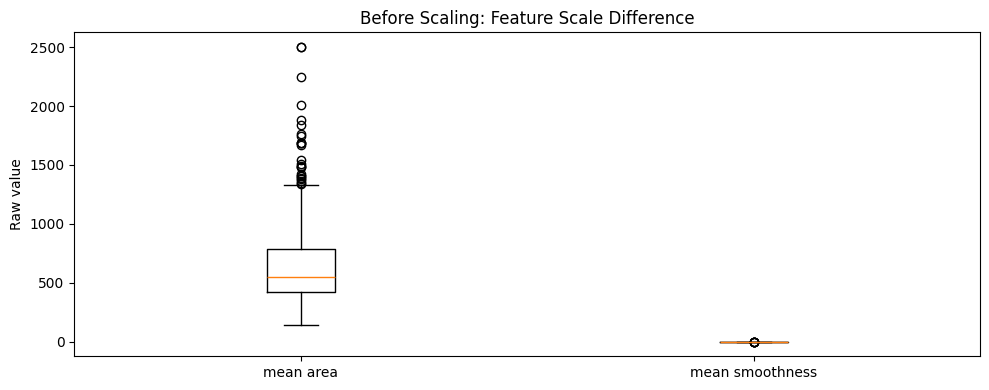

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot([X["mean area"], X["mean smoothness"]], labels=["mean area", "mean smoothness"])
ax.set_title("Before Scaling: Feature Scale Difference")
ax.set_ylabel("Raw value")
plt.tight_layout()
plt.show()


> **🗣️ [발표자 스크립트]**  
> "여기서 핵심은 데이터가 틀렸다는 게 아니라, 단위가 다르다는 점입니다.  
> KNN과 SVM은 이 공간 위에서 거리를 계산하거나 경계를 학습하기 때문에,  
> 이런 스케일 차이를 그대로 두면 특정 feature가 지나치게 큰 영향을 줄 수 있습니다."


## 6. Train / Test Split
- 원칙:
  - **Split 먼저**
  - **Scaler fit은 train만**
- 이번 실습에서는 `stratify=y`를 사용해
  train/test의 클래스 비율이 유사하도록 맞춥니다.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape :", X_test.shape, y_test.shape)

print("\nTrain target ratio")
print(y_train.value_counts(normalize=True).rename(index={0:"malignant",1:"benign"}))

print("\nTest target ratio")
print(y_test.value_counts(normalize=True).rename(index={0:"malignant",1:"benign"}))


Train shape: (455, 30) (455,)
Test shape : (114, 30) (114,)

Train target ratio
target
benign       0.626374
malignant    0.373626
Name: proportion, dtype: float64

Test target ratio
target
benign       0.631579
malignant    0.368421
Name: proportion, dtype: float64


## 7. Baseline 1 — SVM without Scaling
- 먼저 **스케일링 없이** SVM을 학습해 봅니다.
- 이 결과가 오늘 비교의 출발점입니다.


In [9]:
svm_no_scaling = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_no_scaling.fit(X_train, y_train)

pred_svm_no_scaling = svm_no_scaling.predict(X_test)

acc_svm_no_scaling = accuracy_score(y_test, pred_svm_no_scaling)
f1_svm_no_scaling = f1_score(y_test, pred_svm_no_scaling)

print("SVM without scaling")
print("Accuracy:", round(acc_svm_no_scaling, 4))
print("F1-score:", round(f1_svm_no_scaling, 4))


SVM without scaling
Accuracy: 0.9298
F1-score: 0.9459


## 8. Baseline 2 — `StandardScaler + SVM` Pipeline
- 이제 같은 SVM에 `StandardScaler`를 붙여봅니다.
- 중요한 점:
  - 스케일러와 모델을 **하나의 Pipeline** 으로 묶습니다.
  - 이렇게 하면 **train에서만 fit** 되는 구조를 안전하게 유지할 수 있습니다.


In [10]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

svm_pipeline.fit(X_train, y_train)
pred_svm_scaled = svm_pipeline.predict(X_test)

acc_svm_scaled = accuracy_score(y_test, pred_svm_scaled)
f1_svm_scaled = f1_score(y_test, pred_svm_scaled)

print("StandardScaler + SVM")
print("Accuracy:", round(acc_svm_scaled, 4))
print("F1-score:", round(f1_svm_scaled, 4))


StandardScaler + SVM
Accuracy: 0.9825
F1-score: 0.9861


## 9. Baseline 3 — `StandardScaler + KNN` Pipeline
- KNN은 대표적인 **거리 기반 모델**이므로 스케일링 영향이 매우 큽니다.
- 우선 `k=5` 로 시작합니다.
- 이후 필요하면 `k` 값을 바꿔가며 추가 비교할 수 있습니다.


In [11]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train)
pred_knn_scaled = knn_pipeline.predict(X_test)

acc_knn_scaled = accuracy_score(y_test, pred_knn_scaled)
f1_knn_scaled = f1_score(y_test, pred_knn_scaled)

print("StandardScaler + KNN(k=5)")
print("Accuracy:", round(acc_knn_scaled, 4))
print("F1-score:", round(f1_knn_scaled, 4))


StandardScaler + KNN(k=5)
Accuracy: 0.9561
F1-score: 0.9655


## 10. 성능 비교표 만들기
- 이제 실험 결과를 한 표에 정리해 봅니다.
- 비교 단위는 **모델만이 아니라 전처리 + 모델 조합**입니다.


In [12]:
results = pd.DataFrame([
    ["SVM (No Scaling)", acc_svm_no_scaling, f1_svm_no_scaling],
    ["StandardScaler + SVM", acc_svm_scaled, f1_svm_scaled],
    ["StandardScaler + KNN(k=5)", acc_knn_scaled, f1_knn_scaled],
], columns=["experiment", "accuracy", "f1_score"])

results = results.sort_values("f1_score", ascending=False).reset_index(drop=True)
display(results.style.format({"accuracy":"{:.4f}", "f1_score":"{:.4f}"}))


,experiment,accuracy,f1_score
0,StandardScaler + SVM,0.9825,0.9861
1,StandardScaler + KNN(k=5),0.9561,0.9655
2,SVM (No Scaling),0.9298,0.9459


## 11. SVM before/after scaling 차이 해석
- 여기서 반드시 봐야 할 포인트는
  **같은 SVM인데 scaling만 바꿨을 때 성능이 얼마나 달라졌는가** 입니다.
- 이 차이는 곧 **전처리의 영향력**을 보여줍니다.


In [13]:
delta_acc = acc_svm_scaled - acc_svm_no_scaling
delta_f1 = f1_svm_scaled - f1_svm_no_scaling

print("SVM scaling effect")
print("Accuracy improvement:", round(delta_acc, 4))
print("F1 improvement      :", round(delta_f1, 4))


SVM scaling effect
Accuracy improvement: 0.0526
F1 improvement      : 0.0402


## 12. Confusion Matrix 비교
- 단순 Accuracy/F1 외에도
  **어떤 오분류가 줄었는지** 를 보는 것이 중요합니다.
- 아래에서는
  1. scaling 없는 SVM
  2. scaling 있는 SVM
  3. scaling 있는 KNN
  을 각각 비교합니다.


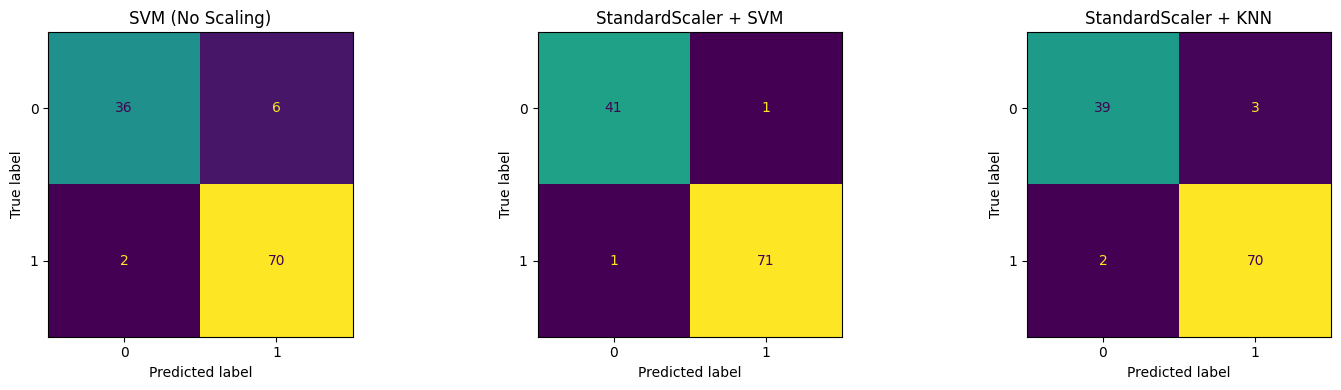

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_svm_no_scaling,
    ax=axes[0], colorbar=False
)
axes[0].set_title("SVM (No Scaling)")

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_svm_scaled,
    ax=axes[1], colorbar=False
)
axes[1].set_title("StandardScaler + SVM")

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_knn_scaled,
    ax=axes[2], colorbar=False
)
axes[2].set_title("StandardScaler + KNN")

plt.tight_layout()
plt.show()


## 13. Classification Report 확인
- Precision / Recall / F1-score를 클래스별로 확인합니다.
- 단순 점수보다 더 세밀한 해석이 가능합니다.


In [15]:
print("[SVM - No Scaling]")
print(classification_report(y_test, pred_svm_no_scaling, target_names=data.target_names))

print("\n[StandardScaler + SVM]")
print(classification_report(y_test, pred_svm_scaled, target_names=data.target_names))

print("\n[StandardScaler + KNN]")
print(classification_report(y_test, pred_knn_scaled, target_names=data.target_names))


[SVM - No Scaling]
              precision    recall  f1-score   support

   malignant       0.95      0.86      0.90        42
      benign       0.92      0.97      0.95        72

    accuracy                           0.93       114
   macro avg       0.93      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114


[StandardScaler + SVM]
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


[StandardScaler + KNN]
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighte

## 14. 추가 실험 — MinMaxScaler + SVM
- StandardScaler 외에 MinMaxScaler를 붙이면 결과가 어떻게 달라질까요?
- 이 셀은 선택 실험입니다.
- 실무에서는 baseline 단계에서 이런 비교를 짧게 해보는 것이 좋습니다.


In [16]:
svm_minmax_pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

svm_minmax_pipeline.fit(X_train, y_train)
pred_svm_minmax = svm_minmax_pipeline.predict(X_test)

acc_svm_minmax = accuracy_score(y_test, pred_svm_minmax)
f1_svm_minmax = f1_score(y_test, pred_svm_minmax)

print("MinMaxScaler + SVM")
print("Accuracy:", round(acc_svm_minmax, 4))
print("F1-score:", round(f1_svm_minmax, 4))


MinMaxScaler + SVM
Accuracy: 0.9825
F1-score: 0.9861


In [17]:
results_ext = pd.DataFrame([
    ["SVM (No Scaling)", acc_svm_no_scaling, f1_svm_no_scaling],
    ["StandardScaler + SVM", acc_svm_scaled, f1_svm_scaled],
    ["MinMaxScaler + SVM", acc_svm_minmax, f1_svm_minmax],
    ["StandardScaler + KNN(k=5)", acc_knn_scaled, f1_knn_scaled],
], columns=["experiment", "accuracy", "f1_score"]).sort_values("f1_score", ascending=False)

display(results_ext.style.format({"accuracy":"{:.4f}", "f1_score":"{:.4f}"}))


,experiment,accuracy,f1_score
1,StandardScaler + SVM,0.9825,0.9861
2,MinMaxScaler + SVM,0.9825,0.9861
3,StandardScaler + KNN(k=5),0.9561,0.9655
0,SVM (No Scaling),0.9298,0.9459


## 15. KNN의 `k` 값에 따라 성능이 어떻게 달라지는지 확인
- `k=1 ~ 15` 범위 정도를 빠르게 비교해 보면
  KNN이 얼마나 민감한지 감을 잡을 수 있습니다.
- 이 역시 baseline 탐색 과정의 일부입니다.


In [18]:
knn_scores = []

for k in range(1, 16):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=k))
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    knn_scores.append({
        "k": k,
        "accuracy": accuracy_score(y_test, pred),
        "f1_score": f1_score(y_test, pred)
    })

knn_scores_df = pd.DataFrame(knn_scores)
display(knn_scores_df)


,k,accuracy,f1_score
0,1,0.938596,0.951049
1,2,0.929825,0.942857
2,3,0.982456,0.986301
3,4,0.947368,0.957746
4,5,0.956140,0.965517
5,6,0.956140,0.965035
6,7,0.973684,0.979592
7,8,0.973684,0.979310
8,9,0.973684,0.979592
9,10,0.964912,0.972603


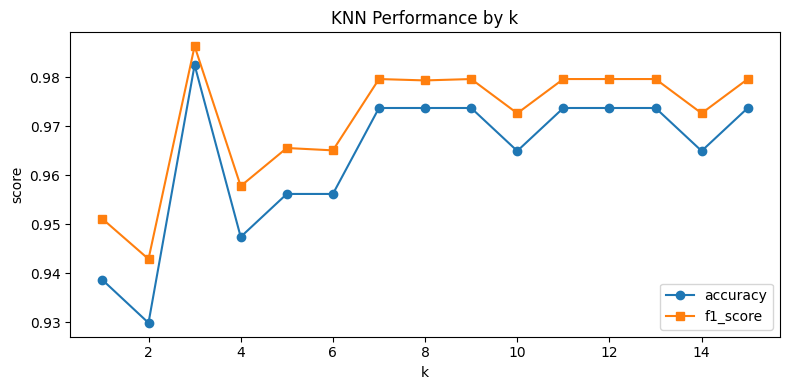

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(knn_scores_df["k"], knn_scores_df["accuracy"], marker="o", label="accuracy")
ax.plot(knn_scores_df["k"], knn_scores_df["f1_score"], marker="s", label="f1_score")
ax.set_title("KNN Performance by k")
ax.set_xlabel("k")
ax.set_ylabel("score")
ax.legend()
plt.tight_layout()
plt.show()


## 16. 실습 해석 템플릿
아래 질문에 답해보면, 오늘 실습 결과를 리포트 문장으로 정리하기 쉽습니다.

1. 스케일링이 없는 SVM과 있는 SVM의 성능 차이는 어느 정도였는가?  
2. 왜 KNN은 스케일링에 민감하다고 볼 수 있는가?  
3. 이번 데이터에서는 KNN과 SVM 중 어떤 접근이 더 잘 맞았는가?  
4. StandardScaler와 MinMaxScaler 중 어떤 방식이 더 적합해 보였는가?  
5. 성능 차이를 단순 점수 외에 confusion matrix 기준으로 어떻게 해석할 수 있는가?


## 17. 과제 2 연결 — Titanic에서는 왜 Pipeline이 더 중요해지는가

오늘 Breast Cancer 데이터는 **전부 수치형**이라서 `Scaler + Model` 만으로 충분했습니다.  
하지만 과제 2의 Titanic 데이터는 다음이 섞여 있습니다.

- 수치형: `Age`, `Fare`, `SibSp`, `Parch` 등
- 범주형: `Sex`, `Embarked`, `Pclass` 등
- 결측치: `Age`, `Embarked` 등

따라서 과제에서는 다음 구조가 권장됩니다.

1. 수치형: 결측치 대체 + 스케일링
2. 범주형: 결측치 대체 + One-hot Encoding
3. 전체를 `ColumnTransformer` 로 묶기
4. 그 뒤에 `KNN` 또는 `SVM` 연결


> **🗣️ [발표자 스크립트]**  
> "오늘 실습은 의도적으로 순수 수치형 데이터를 써서 스케일링 효과를 분명하게 본 것입니다.  
> 하지만 과제로 가면 범주형과 결측치가 등장하므로, 이제는 단순 scaler 하나가 아니라  
> `ColumnTransformer + Pipeline` 구조로 확장해야 합니다."


## 18. Titanic 과제용 Pipeline 템플릿
아래 코드는 **과제 2의 출발점** 으로 사용할 수 있는 템플릿입니다.  
실제로 제출할 때는 데이터 로드, 컬럼 선택, 하이퍼파라미터, 평가 지표 등을 스스로 수정하세요.


In [ ]:
# [과제 2 템플릿] Titanic용 예시 코드
# -----------------------------------
# 아래 코드는 '구조 예시'이며, 실제 제출 시 데이터 경로/컬럼명/실험 내용은 직접 수정해야 합니다.

import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# 예시:
# df = pd.read_csv("titanic.csv")
# target = "Survived"

# numeric_features = ["Age", "Fare", "SibSp", "Parch"]
# categorical_features = ["Pclass", "Sex", "Embarked"]

# X = df[numeric_features + categorical_features]
# y = df[target]

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

# numeric_transformer = Pipeline([
#     ("imputer", SimpleImputer(strategy="median")),
#     ("scaler", StandardScaler())
# ])

# categorical_transformer = Pipeline([
#     ("imputer", SimpleImputer(strategy="most_frequent")),
#     ("onehot", OneHotEncoder(handle_unknown="ignore"))
# ])

# preprocessor = ColumnTransformer([
#     ("num", numeric_transformer, numeric_features),
#     ("cat", categorical_transformer, categorical_features)
# ])

# knn_pipe = Pipeline([
#     ("preprocessor", preprocessor),
#     ("model", KNeighborsClassifier(n_neighbors=5))
# ])

# svm_pipe = Pipeline([
#     ("preprocessor", preprocessor),
#     ("model", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
# ])

# for name, model in [("KNN", knn_pipe), ("SVM", svm_pipe)]:
#     model.fit(X_train, y_train)
#     pred = model.predict(X_test)
#     print(f"{name} Accuracy:", accuracy_score(y_test, pred))
#     print(f"{name} F1-score:", f1_score(y_test, pred))
#     print("-" * 50)


## 19. 과제 제출 시 꼭 들어가야 할 비교 포인트
- KNN vs SVM 중 어느 쪽이 더 좋았는가
- 스케일링이 성능에 어떤 영향을 주었는가
- 범주형 전처리 방식(One-hot)이 어떤 역할을 했는가
- 단순 Accuracy 외에 F1 / Confusion Matrix 기준 해석
- 왜 `Pipeline` 구조가 필요한가

### 과제 보고서 문장 예시
- “Titanic 데이터에서는 범주형 처리와 결측치 처리까지 함께 필요하므로 단순 모델 비교보다 Pipeline 설계가 중요했다.”
- “SVM은 scaling 이후 성능이 개선되었고, 이는 경계 학습 과정이 feature scale에 민감하다는 이론과 일치했다.”
- “KNN은 k 값에 따라 성능 변동이 있었으며, 이는 local pattern 기반 모델의 민감도를 보여준다.”


## 20. Wrap-up

오늘 우리는 다음을 직접 확인했습니다.

1. **스케일링은 거리 기반 / 경계 기반 모델 성능에 큰 영향을 줄 수 있다.**
2. **같은 SVM이라도 scaling 유무에 따라 결과가 달라질 수 있다.**
3. **KNN과 SVM은 데이터를 보는 방식 자체가 다르다.**
4. **비교 단위는 모델이 아니라 `전처리 + 모델` 조합이어야 한다.**
5. **과제 2에서는 `ColumnTransformer + Pipeline` 구조가 핵심이다.**

### 실습 체크아웃 문장
- 나는 스케일링이 필요한 이유를 **거리/경계 관점**에서 설명할 수 있다.
- 나는 KNN과 SVM의 차이를 **이웃 vs 경계**로 설명할 수 있다.
- 나는 Titanic 과제에서 왜 `Pipeline` 이 필요한지 설명할 수 있다.
